In [10]:
import pandas as pd

In [11]:
data = pd.read_csv('merged_similarity_analysis.csv')
data.head(20)

,file_name,similar_file,similarity_100,similarity_200,similarity_350,similarity_500,similarity_750,similarity_1000
0,title_000fafe617351d803c43c1cf03a3830c,title_000fafe617351d803c43c1cf03a3830c,0.406557,0.474840,0.505193,0.545425,0.565756,0.581215
1,title_000fafe617351d803c43c1cf03a3830c,title_007ae424be3f6915cc43a13cbdde5242,0.352807,0.382060,0.407102,0.420848,0.428988,0.434961
2,title_000fafe617351d803c43c1cf03a3830c,title_0101833702d72ed1d6b4ffa2264d21e8,0.305840,0.336645,0.000000,0.000000,0.000000,0.000000
3,title_000fafe617351d803c43c1cf03a3830c,title_016901293c3d740ab6147e0682bfa610,0.000000,0.338824,0.374679,0.396759,0.410166,0.418538
4,title_000fafe617351d803c43c1cf03a3830c,title_01fc8de735a538d4b0cf97ce2df1c750,0.358850,0.408957,0.443339,0.466676,0.481811,0.489813
5,title_000fafe617351d803c43c1cf03a3830c,title_02cff35838d45dad4af354353d5a0674,0.387470,0.433129,0.461597,0.480350,0.491115,0.496799
6,title_000fafe617351d803c43c1cf03a3830c,title_03eb51dcb5d72e2da5346761d9c34bcc,0.370756,0.406886,0.436189,0.454084,0.467188,0.471554
7,title_000fafe617351d803c43c1cf03a3830c,title_03f7384159d366707c6a9745506cd575,0.309585,0.346432,0.377455,0.401866,0.416047,0.423991
8,title_000fafe617351d803c43c1cf03a3830c,title_03f8c68762d6059056f854f69b1b650f,0.317310,0.365296,0.394094,0.413561,0.428304,0.436063
9,title_000fafe617351d803c43c1cf03a3830c,title_04122ed4296305cbf7aadf1e242c759e,0.306313,0.349766,0.381170,0.397255,0.408708,0.414426


C:\Users\dangs\AppData\Local\Temp\ipykernel_7292\214272021.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


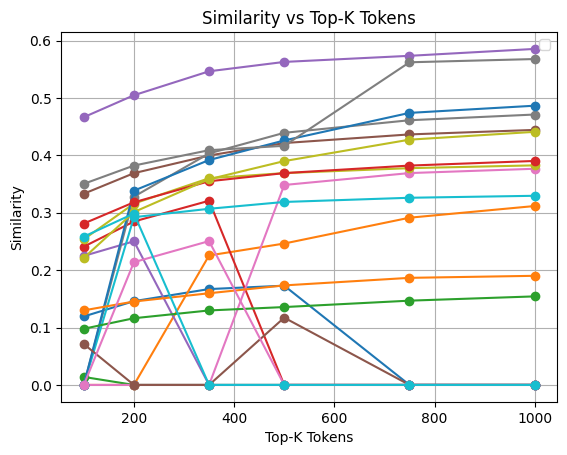

In [21]:
import matplotlib.pyplot as plt

# Select a few rows to visualize
sample_rows = data.sample(n=20)  # Randomly select n rows for plotting

x = [int(col.split("_")[-1]) for col in data.columns[2:]]

for idx, row in sample_rows.iterrows():
    y = row[2:].values.astype(float)
    plt.plot(x, y, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Similarity")
plt.title("Similarity vs Top-K Tokens")
plt.legend()
plt.grid(True)

plt.show()

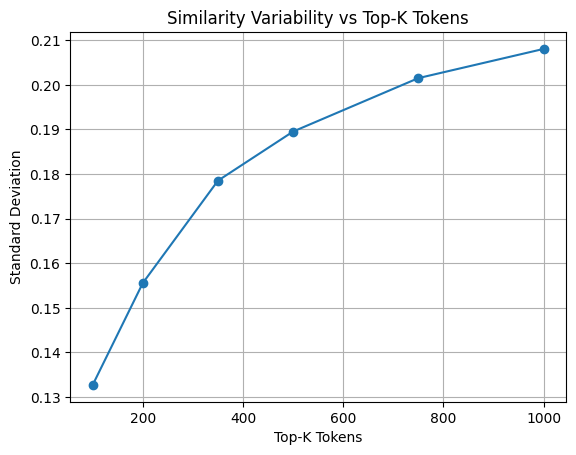

In [26]:
std_dev = data.iloc[:, 2:].std(axis=0)

plt.plot(x, std_dev, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Standard Deviation")
plt.title("Similarity Variability vs Top-K Tokens")
plt.grid(True)

plt.show()

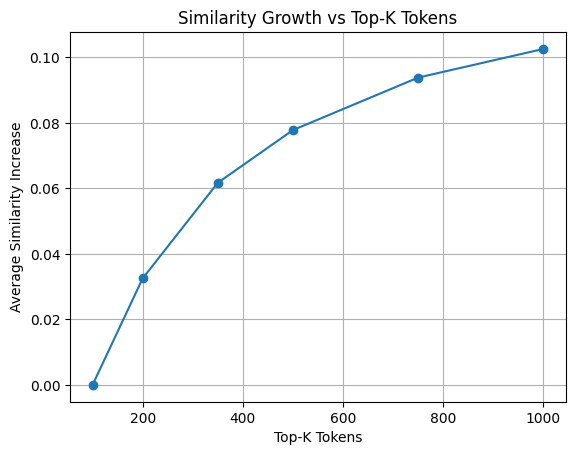

In [27]:
baseline = data["similarity_100"]

growth = data.iloc[:, 2:].subtract(baseline, axis=0)
y = growth.mean(axis=0)

plt.plot(x, y, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Average Similarity Increase")
plt.title("Similarity Growth vs Top-K Tokens")
plt.grid(True)

plt.show()

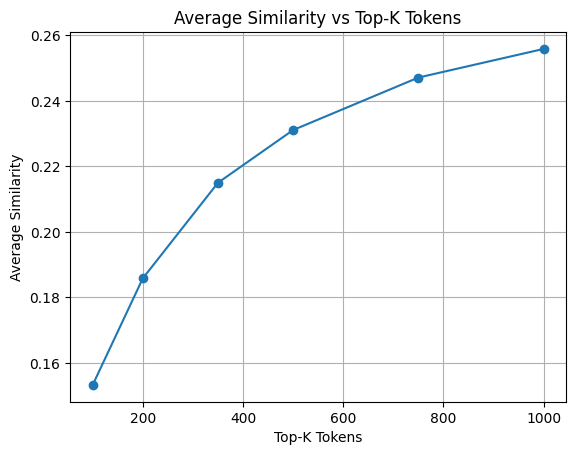

In [28]:
# Compute mean similarity at each TOP_K
y = data.iloc[:, 2:].mean(axis=0)

plt.plot(x, y, marker='o')

plt.xlabel("Top-K Tokens")
plt.ylabel("Average Similarity")
plt.title("Average Similarity vs Top-K Tokens")
plt.grid(True)

plt.show()

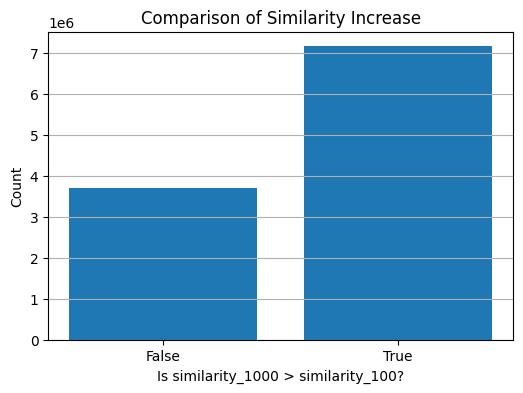

Percentage True: 0.6599610000023023


In [25]:
mask = data['similarity_1000'] > data['similarity_100']

counts = mask.value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['False', 'True'], counts.reindex([False, True], fill_value=0))

plt.xlabel('Is similarity_1000 > similarity_100?')
plt.ylabel('Count')
plt.title('Comparison of Similarity Increase')
plt.grid(axis='y')

plt.show()

print("Percentage True:", mask.mean())

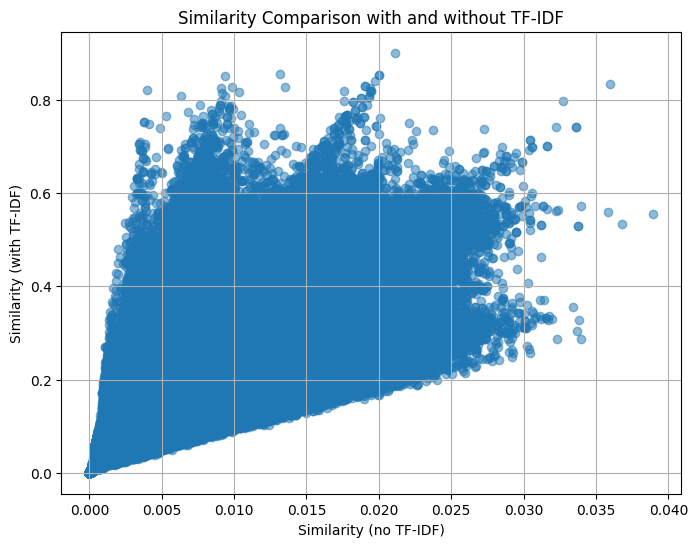

In [32]:
buff_data = pd.read_csv('fun_dataset.csv').iloc[:, -2:] # take last 2 columns
plt.figure(figsize=(8, 6))
plt.scatter(buff_data.iloc[:, 0], buff_data.iloc[:, 1], alpha=0.5)
plt.xlabel('Similarity (no TF-IDF)')
plt.ylabel('Similarity (with TF-IDF)')
plt.title('Similarity Comparison with and without TF-IDF')
plt.grid(True)
plt.show()

In [36]:
import pandas as pd
import numpy as np

# x = raw, y = tfidf
x = buff_data['similarity_no_tf_idf']
y = buff_data['similarity_tf_idf']

# Bin x into intervals
NUM_BINS = 50
bins = np.linspace(x.min(), x.max(), NUM_BINS)

buff_data['bin'] = np.digitize(x, bins)

# Compute quantiles per bin
estimator = buff_data.groupby('bin')['similarity_tf_idf'].agg([
    ('low', lambda s: np.quantile(s, 0.1)),
    ('median', 'median'),
    ('high', lambda s: np.quantile(s, 0.9))
]).reset_index()

# Add bin centers
estimator['x_center'] = bins[estimator['bin'] - 1]

def estimate_range(x_query):
    idx = np.digitize([x_query], bins)[0]
    row = estimator[estimator['bin'] == idx]

    if row.empty:
        return None

    return {
        "low": float(row['low']),
        "median": float(row['median']),
        "high": float(row['high'])
    }

for x in np.linspace(0, 1, 10):
    est = estimate_range(x)
    print(f"Estimate for x={x:.1f}: {est}")

Estimate for x=0.0: None
Estimate for x=0.1: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=0.2: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=0.3: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=0.4: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=0.6: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=0.7: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=0.8: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=0.9: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}
Estimate for x=1.0: {'low': 0.554462194442749, 'median': 0.554462194442749, 'high': 0.554462194442749}


C:\Users\dangs\AppData\Local\Temp\ipykernel_7292\797206470.py:32: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "low": float(row['low']),
C:\Users\dangs\AppData\Local\Temp\ipykernel_7292\797206470.py:33: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "median": float(row['median']),
C:\Users\dangs\AppData\Local\Temp\ipykernel_7292\797206470.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "high": float(row['high'])


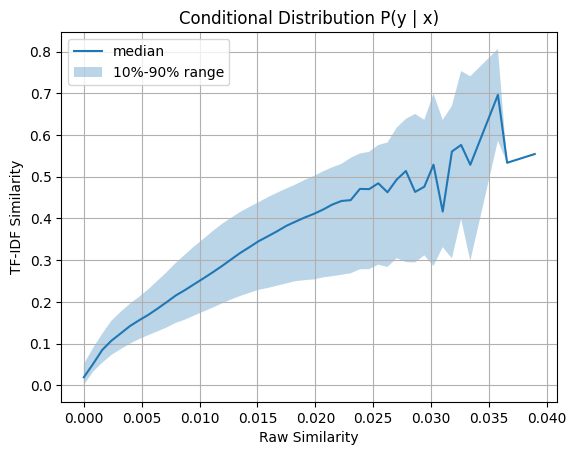

In [37]:
plt.plot(estimator['x_center'], estimator['median'], label='median')
plt.fill_between(
    estimator['x_center'],
    estimator['low'],
    estimator['high'],
    alpha=0.3,
    label='10%-90% range'
)

plt.xlabel("Raw Similarity")
plt.ylabel("TF-IDF Similarity")
plt.title("Conditional Distribution P(y | x)")
plt.legend()
plt.grid(True)
plt.show()